# 🧪 당뇨병 데이터 분석 (EDA Report)

## 1. 서론 (Introduction)

본 데이터셋은 환자의 의료 정보를 기반으로 당뇨병 여부를 예측하기 위한 데이터이다.  
주요 변수로는 혈당 수치(plas), BMI(mass), 나이(age) 등이 포함되어 있다.

본 분석의 목적은 데이터의 패턴을 탐색하고, 당뇨병에 영향을 미치는 주요 요인을 파악하는 것이다.

## 주요 분석 질문 (Key Questions)

- 혈당 수치는 당뇨병 여부에 어떤 영향을 미치는가?
- BMI는 당뇨병과 어떤 관계가 있는가?
- 나이는 당뇨병 발생에 영향을 주는가?

In [30]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name='diabetes', version=1, as_frame=True)
df = data.frame

df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


## 2. 데이터 프로파일링 (Data Profiling)

In [21]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   preg    768 non-null    int64   
 1   plas    768 non-null    int64   
 2   pres    768 non-null    int64   
 3   skin    768 non-null    int64   
 4   insu    768 non-null    int64   
 5   mass    768 non-null    float64 
 6   pedi    768 non-null    float64 
 7   age     768 non-null    int64   
 8   class   768 non-null    category
dtypes: category(1), float64(2), int64(6)
memory usage: 49.0 KB


,0
preg,0
plas,0
pres,0
skin,0
insu,0
mass,0
pedi,0
age,0
class,0


### 분석 결과
- 데이터는 대부분 수치형 변수로 구성되어 있다.
- 결측치는 거의 존재하지 않으며 데이터 품질이 양호하다.

## 3. 변수별 개별 특성 분석 (Univariate Analysis)

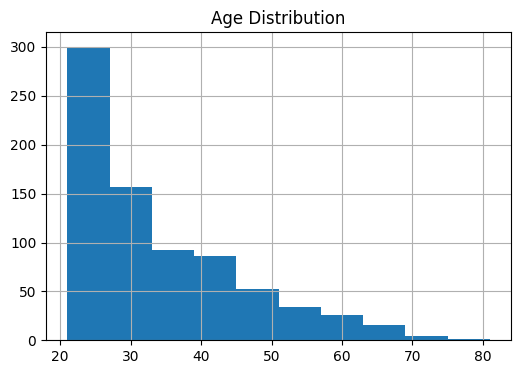

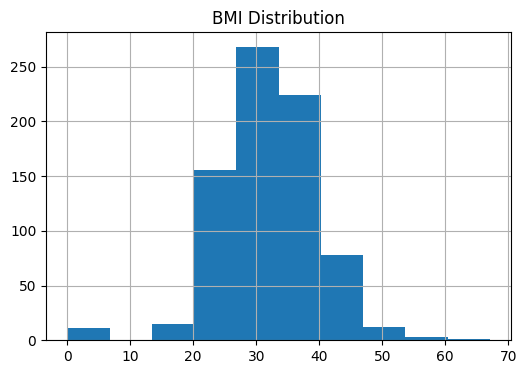

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
df["age"].hist()
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6,4))
df["mass"].hist()
plt.title("BMI Distribution")
plt.show()

### 분석 결과
- 대부분의 환자는 중년층에 집중되어 있다.
- BMI 값은 다양한 분포를 보이며 건강 상태의 차이를 나타낸다.

## 4. 다변량 분석 (Multivariate Analysis)

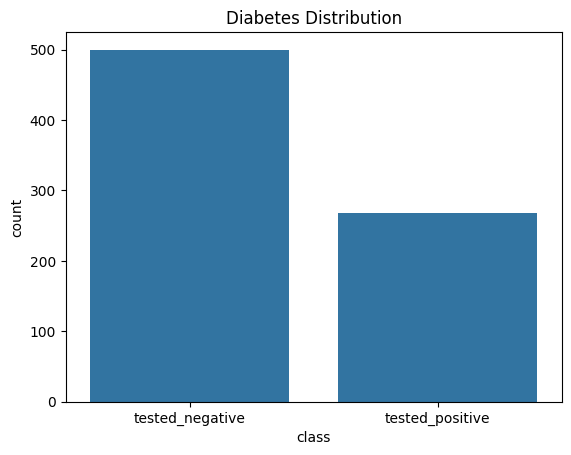

In [23]:
sns.countplot(x="class", data=df)
plt.title("Diabetes Distribution")
plt.show()

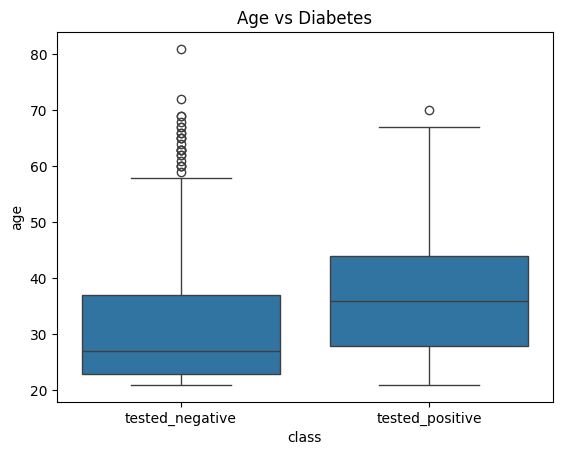

In [24]:
sns.boxplot(x="class", y="age", data=df)
plt.title("Age vs Diabetes")
plt.show()

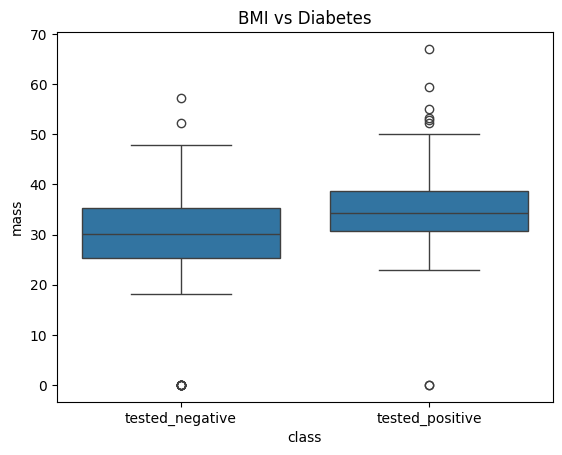

In [25]:
sns.boxplot(x="class", y="mass", data=df)
plt.title("BMI vs Diabetes")
plt.show()

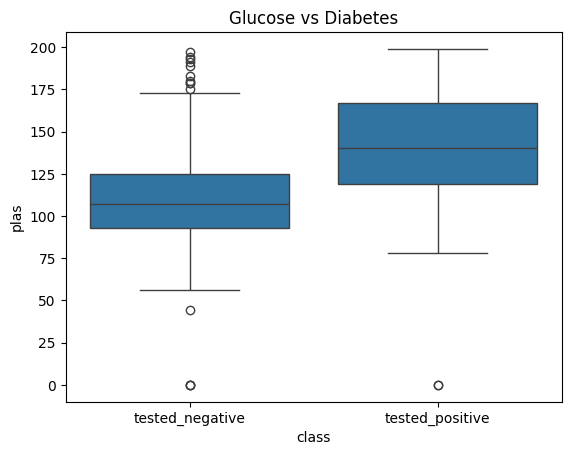

In [26]:
sns.boxplot(x="class", y="plas", data=df)
plt.title("Glucose vs Diabetes")
plt.show()

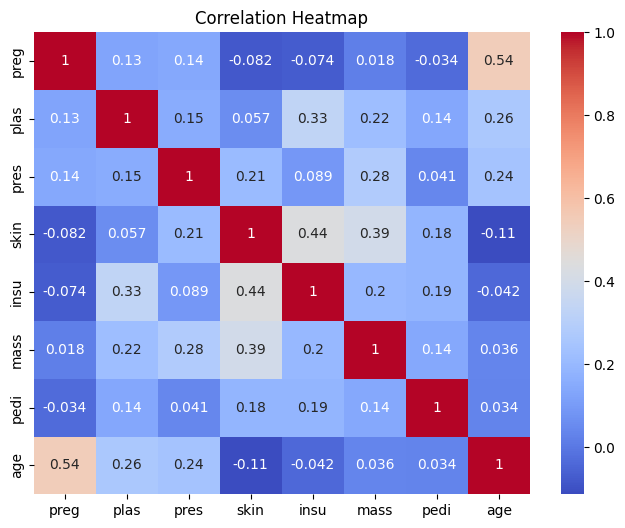

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 분석 결과

- 혈당 수치(plas)가 높을수록 당뇨병일 가능성이 높다.
- BMI 또한 당뇨병과 높은 관련성을 보인다.
- 일부 변수 간에는 중간 정도의 상관관계가 존재한다.
- 당뇨병 환자는 평균적으로 나이가 더 높은 경향을 보인다.
- 인슐린(insu) 및 피부 두께(skin)와 같은 변수는 상대적으로 낮은 상관관계를 보였다.
- 변수 간 상관관계는 존재하지만, 단일 변수만으로 당뇨병을 완전히 설명하기에는 한계가 있다.

## 5. 핵심 인사이트 (Key Insights)

- 혈당 수치는 당뇨병 여부를 판단하는 가장 중요한 변수이다.
- BMI가 높을수록 당뇨병 위험이 증가한다.
- 나이 역시 당뇨병 발생에 영향을 미치는 요소이다.

## 6. 결론 (Conclusion)

본 분석을 통해 혈당 수치, BMI, 나이 등이 당뇨병과 밀접한 관련이 있음을 확인하였다.

이러한 결과는 조기 진단 및 예방 전략 수립에 활용될 수 있다.

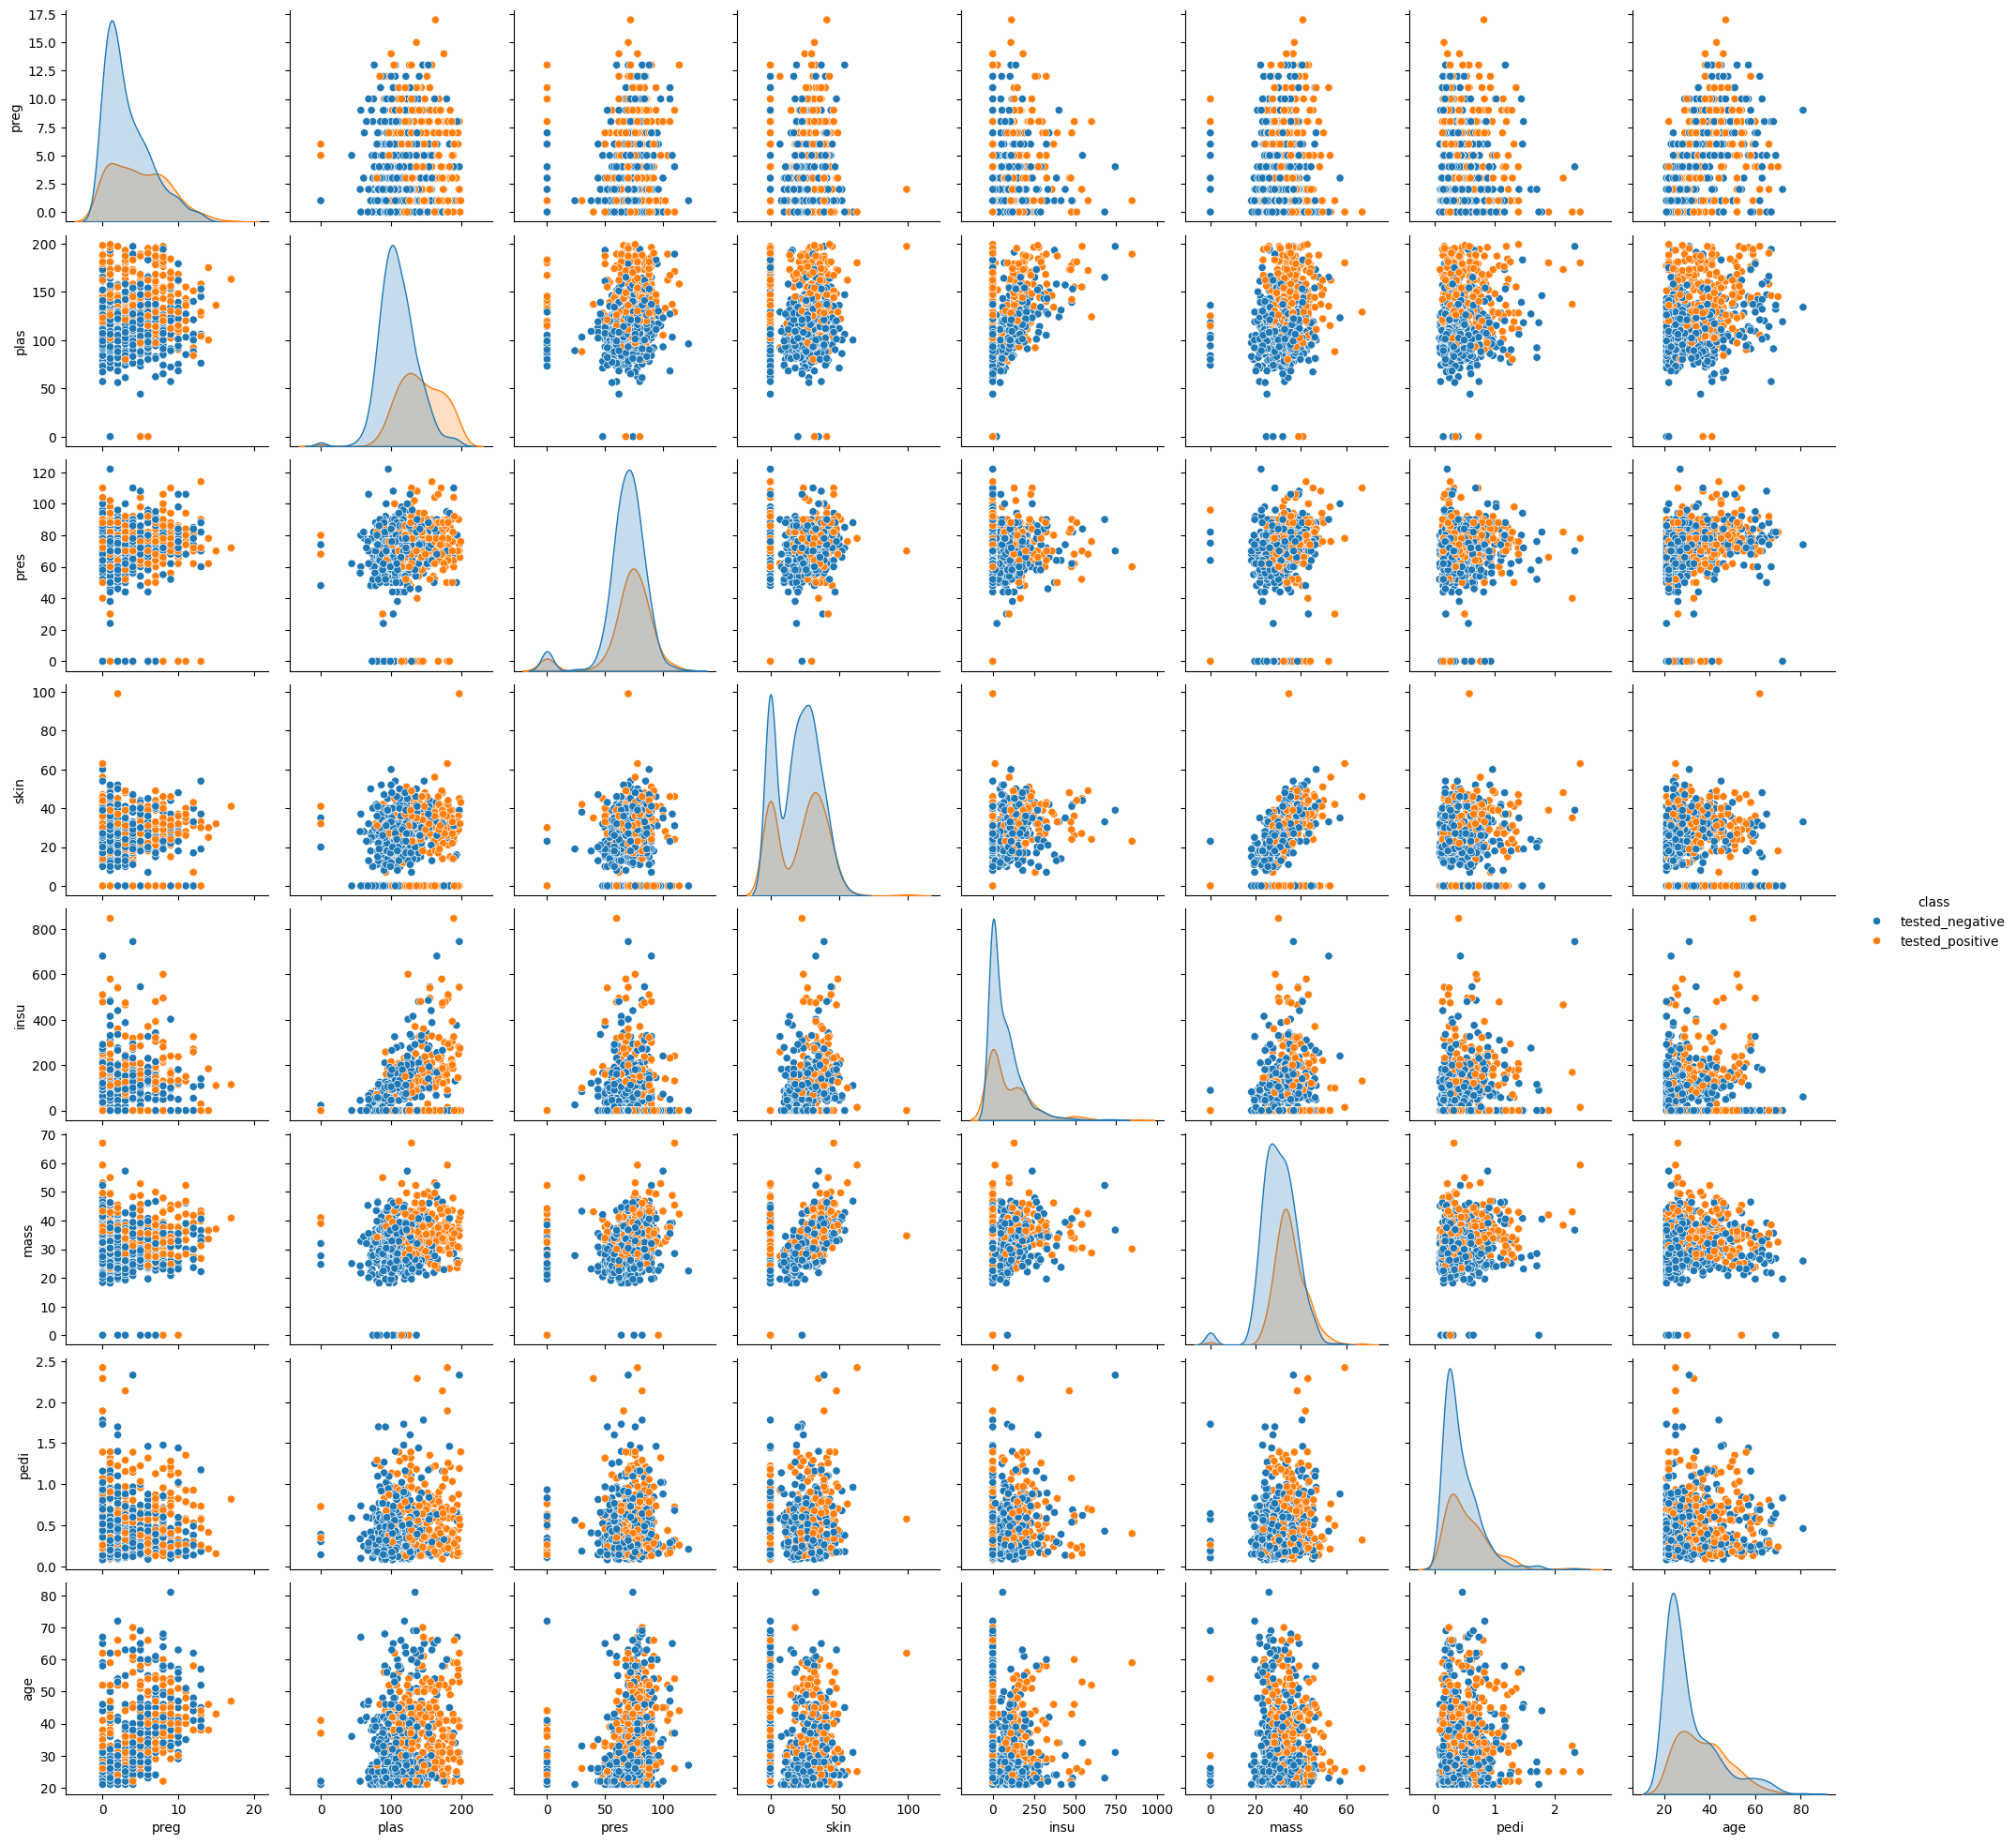

In [28]:
sns.pairplot(df, hue="class")